## **CELL 1 — Download + Extract UCI-HAR Dataset**

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip -O UCI_HAR_Dataset.zip
!unzip -q UCI_HAR_Dataset.zip

base_path = "/content/UCI HAR Dataset/"
print("Dataset downloaded and extracted successfully.")

--2026-02-18 20:24:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI_HAR_Dataset.zip’

UCI_HAR_Dataset.zip     [       <=>          ]  58.17M  44.6MB/s    in 1.3s    

2026-02-18 20:24:33 (44.6 MB/s) - ‘UCI_HAR_Dataset.zip’ saved [60999314]

Dataset downloaded and extracted successfully.


# `**Import Libraries**`

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, log_loss
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## ***Load Pre-Extracted Training & Testing Data***

In [ ]:
X_train = pd.read_csv(base_path + "train/X_train.txt", sep=r'\s+', header=None)
X_test  = pd.read_csv(base_path + "test/X_test.txt",  sep=r'\s+', header=None)
y_train = pd.read_csv(base_path + "train/y_train.txt", header=None)[0]
y_test  = pd.read_csv(base_path + "test/y_test.txt",  header=None)[0]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Unique labels:", y_train.unique())

X_train shape: (7352, 561)
X_test shape: (2947, 561)
Unique labels: [5 4 6 1 3 2]


### ***Scaling***

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


### ***PCA Dimensionality Reduction***

In [ ]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original dimensions:", X_train.shape[1])
print("Reduced PCA dimensions:", X_train_pca.shape[1])

Original dimensions: 561
Reduced PCA dimensions: 102


### ***Explore Feature Names***

In [ ]:
features_path = "/content/UCI HAR Dataset/features.txt"
feature_names = pd.read_csv(features_path, sep=r'\s+', header=None)[1].tolist()

print("First 30 Features:")
for i, name in enumerate(feature_names[:30], 1):
    print(f"{i:3d}. {name}")

print("\nLast 10 Features:")
for i, name in enumerate(feature_names[-10:], 552):
    print(f"{i:3d}. {name}")

# Count categories
categories = {
    "Body Acceleration": sum("tBodyAcc" in f for f in feature_names),
    "Gravity Acceleration": sum("tGravityAcc" in f for f in feature_names),
    "Body Jerk": sum("tBodyAccJerk" in f for f in feature_names),
    "Gyroscope": sum("tBodyGyro" in f for f in feature_names),
    "Frequency Domain": sum("fBody" in f for f in feature_names)
}

print("\nFeature Categories Count:")
for cat, count in categories.items():
    print(f"{cat}: {count}")


First 30 Features:
  1. tBodyAcc-mean()-X
  2. tBodyAcc-mean()-Y
  3. tBodyAcc-mean()-Z
  4. tBodyAcc-std()-X
  5. tBodyAcc-std()-Y
  6. tBodyAcc-std()-Z
  7. tBodyAcc-mad()-X
  8. tBodyAcc-mad()-Y
  9. tBodyAcc-mad()-Z
 10. tBodyAcc-max()-X
 11. tBodyAcc-max()-Y
 12. tBodyAcc-max()-Z
 13. tBodyAcc-min()-X
 14. tBodyAcc-min()-Y
 15. tBodyAcc-min()-Z
 16. tBodyAcc-sma()
 17. tBodyAcc-energy()-X
 18. tBodyAcc-energy()-Y
 19. tBodyAcc-energy()-Z
 20. tBodyAcc-iqr()-X
 21. tBodyAcc-iqr()-Y
 22. tBodyAcc-iqr()-Z
 23. tBodyAcc-entropy()-X
 24. tBodyAcc-entropy()-Y
 25. tBodyAcc-entropy()-Z
 26. tBodyAcc-arCoeff()-X,1
 27. tBodyAcc-arCoeff()-X,2
 28. tBodyAcc-arCoeff()-X,3
 29. tBodyAcc-arCoeff()-X,4
 30. tBodyAcc-arCoeff()-Y,1

Last 10 Features:
552. fBodyBodyGyroJerkMag-meanFreq()
553. fBodyBodyGyroJerkMag-skewness()
554. fBodyBodyGyroJerkMag-kurtosis()
555. angle(tBodyAccMean,gravity)
556. angle(tBodyAccJerkMean),gravityMean)
557. angle(tBodyGyroMean,gravityMean)
558. angle(tBodyGyroJerkMe

### ***Train Logistic Regression + Evaluate***

In [ ]:
log_clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
log_clf.fit(X_train_pca, y_train)

y_pred_log = log_clf.predict(X_test_pca)
y_proba_log = log_clf.predict_proba(X_test_pca)

log_acc = accuracy_score(y_test, y_pred_log)
log_prec = precision_score(y_test, y_pred_log, average="macro")
log_ll = log_loss(y_test, y_proba_log)

print("=== Logistic Regression Results ===")
print("Accuracy :", log_acc)
print("Precision:", log_prec)
print("Log Loss :", log_ll)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression Results ===
Accuracy : 0.9314557176789956
Precision: 0.9316842270268099
Log Loss : 0.21274819454713792


### ***Train Random Forest + Evaluate***

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_pca, y_train)

y_pred_rf = rf_clf.predict(X_test_pca)
y_proba_rf = rf_clf.predict_proba(X_test_pca)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average="macro")
rf_ll = log_loss(y_test, y_proba_rf)

print("=== Random Forest Results ===")
print("Accuracy :", rf_acc)
print("Precision:", rf_prec)
print("Log Loss :", rf_ll)

=== Random Forest Results ===
Accuracy : 0.8866644044791313
Precision: 0.8903490700230972
Log Loss : 0.5172153664566616


### ***Logistic Regression Complexity–Loss Curve***

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

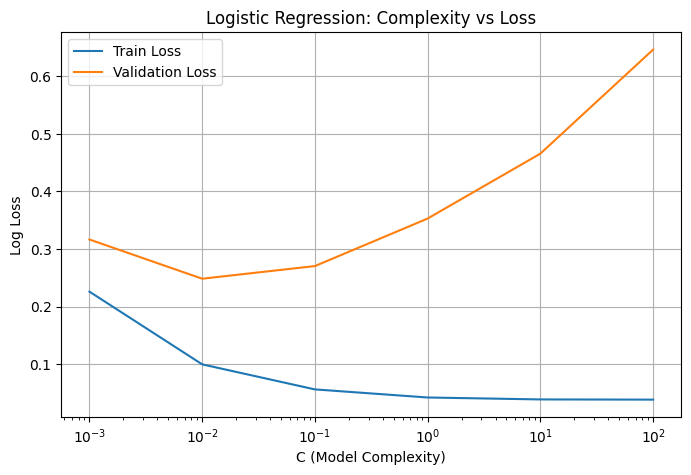

In [ ]:
C_values = np.logspace(-3, 2, 6)

train_scores, val_scores = validation_curve(
    LogisticRegression(max_iter=1000, multi_class="multinomial"),
    X_train_pca,
    y_train,
    param_name="C",
    param_range=C_values,
    cv=5,
    scoring="neg_log_loss"
)

train_loss = -train_scores.mean(axis=1)
val_loss = -val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.semilogx(C_values, train_loss, label="Train Loss")
plt.semilogx(C_values, val_loss, label="Validation Loss")
plt.xlabel("C (Model Complexity)")
plt.ylabel("Log Loss")
plt.title("Logistic Regression: Complexity vs Loss")
plt.legend()
plt.grid(True)
plt.show()

### ***Random Forest Complexity–Loss Curve***

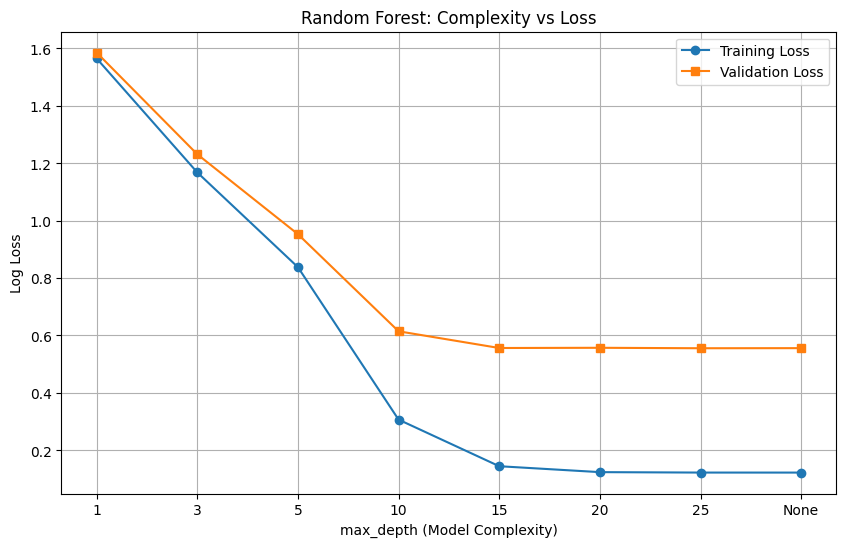

In [ ]:
depth_values = [1, 3, 5, 10, 15, 20, 25, None]

train_losses_rf, val_losses_rf = validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X_train_pca,
    y_train,
    param_name="max_depth",
    param_range=depth_values,
    cv=5,
    scoring="neg_log_loss"
)

train_loss_rf = -train_losses_rf.mean(axis=1)
val_loss_rf = -val_losses_rf.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(range(len(depth_values)), train_loss_rf, 'o-', label="Training Loss")
plt.plot(range(len(depth_values)), val_loss_rf, 's-', label="Validation Loss")
plt.xticks(range(len(depth_values)), [str(d) for d in depth_values])
plt.xlabel("max_depth (Model Complexity)")
plt.ylabel("Log Loss")
plt.title("Random Forest: Complexity vs Loss")
plt.legend()
plt.grid(True)
plt.show()

### ***Plot Accuracy for Logistic vs Random Forest***

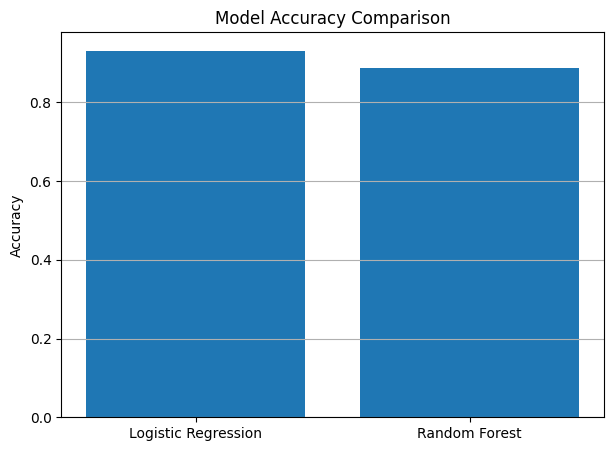

In [ ]:
# ======================================================
# CELL 11 — Compare Accuracy: Logistic vs Random Forest
# ======================================================

plt.figure(figsize=(7,5))
models = ["Logistic Regression", "Random Forest"]
accuracy_values = [log_acc, rf_acc]

plt.bar(models, accuracy_values)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.grid(axis="y")
plt.show()


### ***Final Interpretation***

In [ ]:
print("=== Interpretation ===")
print("Low depth (1–3): High loss → Underfitting")
print("High depth (20+): Train loss very low, validation loss increases → Overfitting")
print("Middle depth (5–15): Train/validation loss both low → Good fit")

=== Interpretation ===
Low depth (1–3): High loss → Underfitting
High depth (20+): Train loss very low, validation loss increases → Overfitting
Middle depth (5–15): Train/validation loss both low → Good fit
